In [1]:
docs = ['go india',
		'india india',
		'hip hip hurray',
		'jeetega bhai jeetega india jeetega',
		'bharat mata ki jai',
		'kohli kohli',
		'sachin sachin',
		'dhoni dhoni',
		'modi ji ki jai',
		'inquilab zindabad']

In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()

In [4]:
tokenizer.fit_on_texts(docs)

In [5]:
len(tokenizer.word_index)

17

In [6]:
sequences = tokenizer.texts_to_sequences(docs)
sequences

[[9, 1],
 [1, 1],
 [3, 3, 10],
 [2, 11, 2, 1, 2],
 [12, 13, 4, 5],
 [6, 6],
 [7, 7],
 [8, 8],
 [14, 15, 4, 5],
 [16, 17]]

In [7]:
from keras.utils import pad_sequences
sequences = pad_sequences(sequences,padding='post')
sequences

array([[ 9,  1,  0,  0,  0],
       [ 1,  1,  0,  0,  0],
       [ 3,  3, 10,  0,  0],
       [ 2, 11,  2,  1,  2],
       [12, 13,  4,  5,  0],
       [ 6,  6,  0,  0,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [14, 15,  4,  5,  0],
       [16, 17,  0,  0,  0]], dtype=int32)

In [11]:
from keras.layers import *
from keras import Sequential

In [12]:
model = Sequential()
model.add(Embedding(17,output_dim=2,input_length=5))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile('adam','accuracy')

In [ ]:
pred = model.predict(sequences)
print(pred)

1/1 [==============================] - 0s 15ms/step
[[[-0.03378457 -0.0223366 ]
  [-0.01869411  0.0397962 ]
  [ 0.04738592  0.03497881]
  [ 0.04738592  0.03497881]
  [ 0.04738592  0.03497881]]

 [[-0.01869411  0.0397962 ]
  [-0.01869411  0.0397962 ]
  [ 0.04738592  0.03497881]
  [ 0.04738592  0.03497881]
  [ 0.04738592  0.03497881]]

 [[ 0.00716299  0.02782274]
  [ 0.00716299  0.02782274]
  [-0.02727993 -0.02907238]
  [ 0.04738592  0.03497881]
  [ 0.04738592  0.03497881]]

 [[ 0.04634063 -0.01492285]
  [ 0.04544855 -0.02214533]
  [ 0.04634063 -0.01492285]
  [-0.01869411  0.0397962 ]
  [ 0.04634063 -0.01492285]]

 [[ 0.03687553  0.00542127]
  [ 0.00882751  0.02693466]
  [ 0.00960891 -0.02113671]
  [-0.01385436  0.00159916]
  [ 0.04738592  0.03497881]]

 [[ 0.04272473 -0.02110641]
  [ 0.04272473 -0.02110641]
  [ 0.04738592  0.03497881]
  [ 0.04738592  0.03497881]
  [ 0.04738592  0.03497881]]

 [[ 0.01033523 -0.02812191]
  [ 0.01033523 -0.02812191]
  [ 0.04738592  0.03497881]
  [ 0.047385

In [13]:
from keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten

In [14]:
(X_train,y_train),(X_test,y_test) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
X_train = pad_sequences(X_train,padding='post',maxlen=50)
X_test = pad_sequences(X_test,padding='post',maxlen=50)

In [16]:
X_train.shape

(25000, 50)

In [21]:
model = Sequential()
model.add(Embedding(10000, output_dim = 2)) # Word Dimension - more than 10000 - but for simplicity we put 10000.
                                  # 2 - Output Dimension
                                  # 50 - Input Row Dimension (Number of words per input row (We have chosen first 50 words only))
model.add(SimpleRNN(32,return_sequences=False))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train,epochs=5,validation_data=(X_test,y_test))

Epoch 1/5
782/782 [==============================] - 40s 50ms/step - loss: 0.5801 - acc: 0.6731 - val_loss: 0.4433 - val_acc: 0.7978
Epoch 2/5
782/782 [==============================] - 39s 50ms/step - loss: 0.3524 - acc: 0.8510 - val_loss: 0.4430 - val_acc: 0.8051
Epoch 3/5
782/782 [==============================] - 39s 50ms/step - loss: 0.2040 - acc: 0.9224 - val_loss: 0.5460 - val_acc: 0.7828
Epoch 4/5
782/782 [==============================] - 38s 49ms/step - loss: 0.0823 - acc: 0.9735 - val_loss: 0.6990 - val_acc: 0.7824
Epoch 5/5
782/782 [==============================] - 38s 49ms/step - loss: 0.0352 - acc: 0.9894 - val_loss: 0.8774 - val_acc: 0.7670


# Task
Review the training results, including loss and accuracy on both training and validation sets, to evaluate the model's performance.

## Define Model Architecture

### Subtask:
Construct a Keras Sequential model that includes an Embedding layer, a SimpleRNN layer, and a Dense output layer for classification. We'll use parameters similar to the previous IMDb example for consistency, such as an embedding input dimension of 10000, output dimension of 32, and SimpleRNN units of 32.


**Reasoning**:
I need to construct a Keras Sequential model with an Embedding layer, a SimpleRNN layer, and a Dense output layer, then print its summary as per the instructions.



In [22]:
model = Sequential()
model.add(Embedding(10000, output_dim=32)) # input_dim = 10000, output_dim = 32
model.add(SimpleRNN(32, return_sequences=False)) # units = 32, return_sequences = False
model.add(Dense(1, activation='sigmoid')) # 1 unit for binary classification, sigmoid activation

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

### Subtask:
Compile the newly defined model using an appropriate optimizer, a loss function suitable for binary classification, and specify accuracy as a metric.


**Reasoning**:
I need to compile the Keras model as instructed, using 'adam' optimizer, 'binary_crossentropy' loss, and 'acc' as a metric. This will prepare the model for training.



In [23]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print("Model compiled successfully.")

Model compiled successfully.


## Train the Model

### Subtask:
Train the compiled model using the `X_train` and `y_train` datasets, and include `X_test` and `y_test` for validation to monitor performance during training.


**Reasoning**:
To train the model as per the subtask's instructions, I need to call the `fit` method on the compiled model, passing in the training and validation data, and specifying the number of epochs.



In [24]:
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))
print("Model training complete.")

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - acc: 0.6219 - loss: 0.6194 - val_acc: 0.7858 - val_loss: 0.4559
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.8501 - loss: 0.3516 - val_acc: 0.7966 - val_loss: 0.4538
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.9394 - loss: 0.1756 - val_acc: 0.7818 - val_loss: 0.5612
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.9800 - loss: 0.0689 - val_acc: 0.7714 - val_loss: 0.7537
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.9932 - loss: 0.0273 - val_acc: 0.7477 - val_loss: 0.8936
Model training complete.


**Reasoning**:
To effectively review the training results, plotting the training and validation loss and accuracy over epochs provides a clear visual evaluation of the model's performance, including identifying potential overfitting or underfitting.



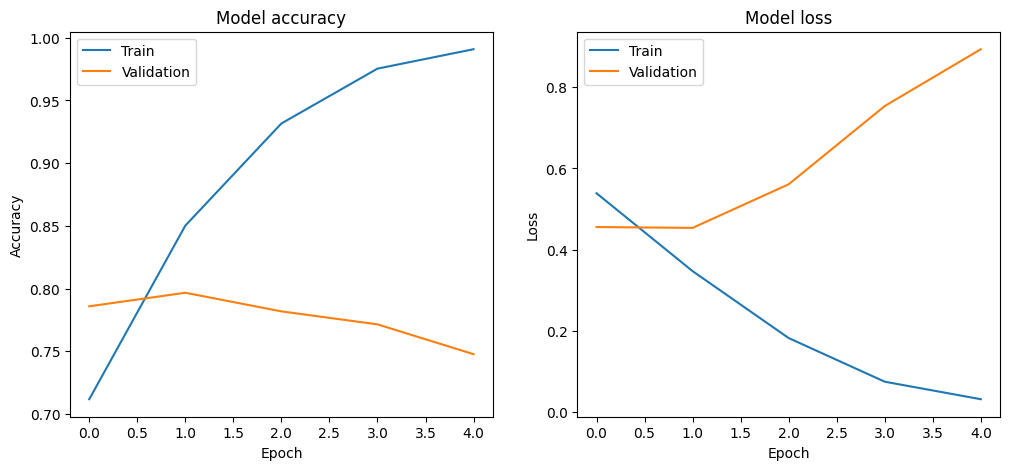

Review of training results complete. The plots show the model's accuracy and loss over epochs for both training and validation datasets.


In [25]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

print("Review of training results complete. The plots show the model's accuracy and loss over epochs for both training and validation datasets.")

## Final Task

### Subtask:
Review the training results, including loss and accuracy on both training and validation sets, to evaluate the model's performance.


## Summary:

### Q&A
The model's performance indicates significant overfitting. While the training accuracy rapidly improved from approximately 62.17\% in Epoch 1 to 99.32\% in Epoch 5, the validation accuracy peaked at 79.66\% in Epoch 2 and subsequently declined to 74.77\% by Epoch 5. This divergence, coupled with the validation loss starting to increase after Epoch 2, confirms that the model is learning the training data too specifically and not generalizing well to unseen data.

### Data Analysis Key Findings
*   The Keras Sequential model was constructed with an Embedding layer (input\_dim=10000, output\_dim=32), a SimpleRNN layer (units=32), and a Dense output layer with sigmoid activation.
*   The model was compiled using the `adam` optimizer, `binary_crossentropy` loss function, and `acc` (accuracy) as a metric.
*   During training over 5 epochs, the training accuracy consistently improved from 62.17\% (Epoch 1) to 99.32\% (Epoch 5).
*   Validation accuracy, however, peaked at 79.66\% in Epoch 2 and then declined, reaching 74.77\% by Epoch 5.
*   The training loss continuously decreased throughout the epochs, while the validation loss initially decreased but began to increase after Epoch 2.

### Insights or Next Steps
*   The model shows clear signs of overfitting, as evidenced by the high training accuracy/low training loss and the diverging validation accuracy/increasing validation loss after the second epoch.
*   To address overfitting, consider implementing early stopping based on validation loss, applying regularization techniques such as dropout, or simplifying the model architecture.
